### Import the Dependencies

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 
from PIL import Image   # to handle image processing
import tensorflow as tf
from tensorflow import keras     # to build the neural network model
from keras.datasets import mnist # to load the MNIST dataset
from tensorflow.math import confusion_matrix

tf.random.set_seed(3)

### Load the dataset

In [70]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [71]:
type(x_train)

numpy.ndarray

In [72]:
# shae of the numpy arrays
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


> ---
> **Insights**
>   - Training data = 60,000 images
>   - Test data     = 10,000 images
>   - Image size    = 28 x 28
>   - Grayscale Image --> 1 Channel
> ---

In [73]:
# printing the image
print(x_train[5])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  13  25 100
  122   7   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  33 151 208 252 252
  252 146   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  40 152 244 252 253 224 211
  252 232  40   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  15 152 239 252 252 252 21

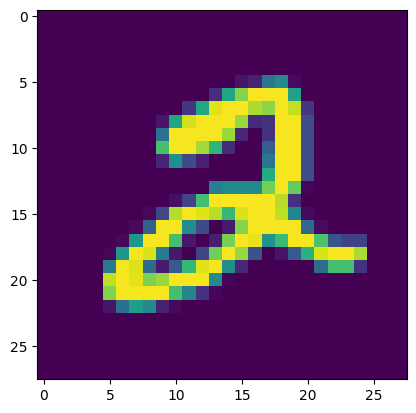

2


In [74]:
# plotting the image
plt.imshow(x_train[5])
plt.show()

print(y_train[5])

In [75]:
# unique values
print(np.unique(y_train))

[0 1 2 3 4 5 6 7 8 9]


In [76]:
# scaling the data
x_train = x_train / 255
x_test = x_test / 255

### Building the Neural Network

In [77]:
# setting up the layers of the model
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# compilling the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [79]:
# train the model
history = model.fit(x_train, y_train, epochs=15, validation_split = 0.1)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8961 - loss: 0.3395 - val_accuracy: 0.9660 - val_loss: 0.1136
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9511 - loss: 0.1597 - val_accuracy: 0.9713 - val_loss: 0.0945
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9613 - loss: 0.1258 - val_accuracy: 0.9773 - val_loss: 0.0813
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9678 - loss: 0.1046 - val_accuracy: 0.9770 - val_loss: 0.0771
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9723 - loss: 0.0891 - val_accuracy: 0.9757 - val_loss: 0.0845
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9740 - loss: 0.0842 - val_accuracy: 0.9778 - val_loss: 0.0773
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9750 - loss: 0.0776 - val_accuracy: 0.9768 - val_loss: 0.0789
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9779 - loss: 0.0696 - 

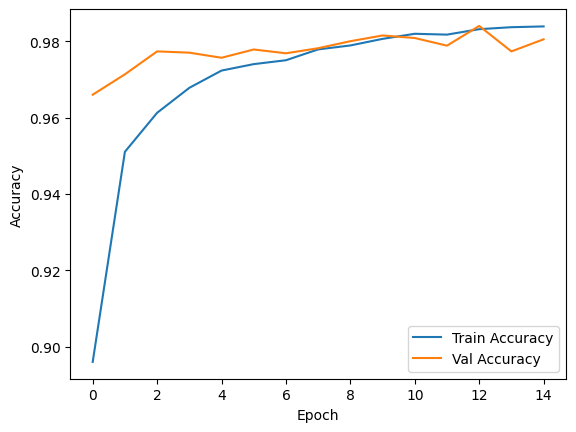

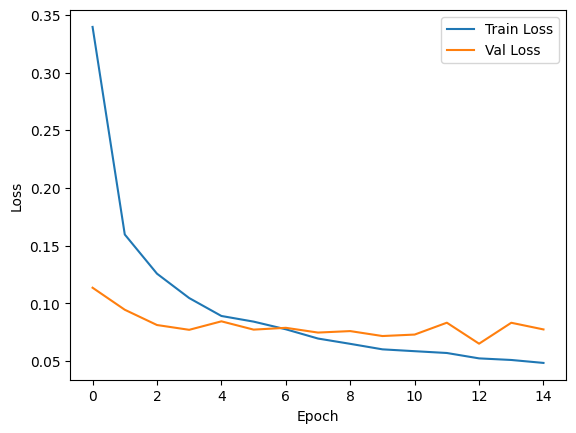

In [80]:
# ✅ Accuracy curves
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# ✅ Loss curves
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Model Evaluation

In [81]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9790 - loss: 0.0839
Loss: 0.08387980610132217
Accuracy: 0.9789999723434448


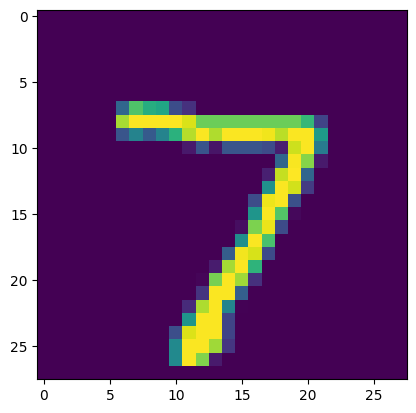

7


In [82]:
# first data point in the test set
plt.imshow(x_test[0])
plt.show()
print(y_test[0])

In [83]:
y_pred = model.predict(x_test)  # it gives the prediction probability for each class

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [84]:
print(y_pred[0])

[5.3926687e-08 2.4470273e-07 1.2025433e-06 5.8978935e-06 2.8768962e-08
 4.4716774e-08 2.1823265e-14 9.9998391e-01 6.6496958e-10 8.6142309e-06]


In [85]:
# convert the prediction probability to class label
label_for_first_image = np.argmax(y_pred[0])
print(label_for_first_image)

7


In [86]:
y_pred_labels = [np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

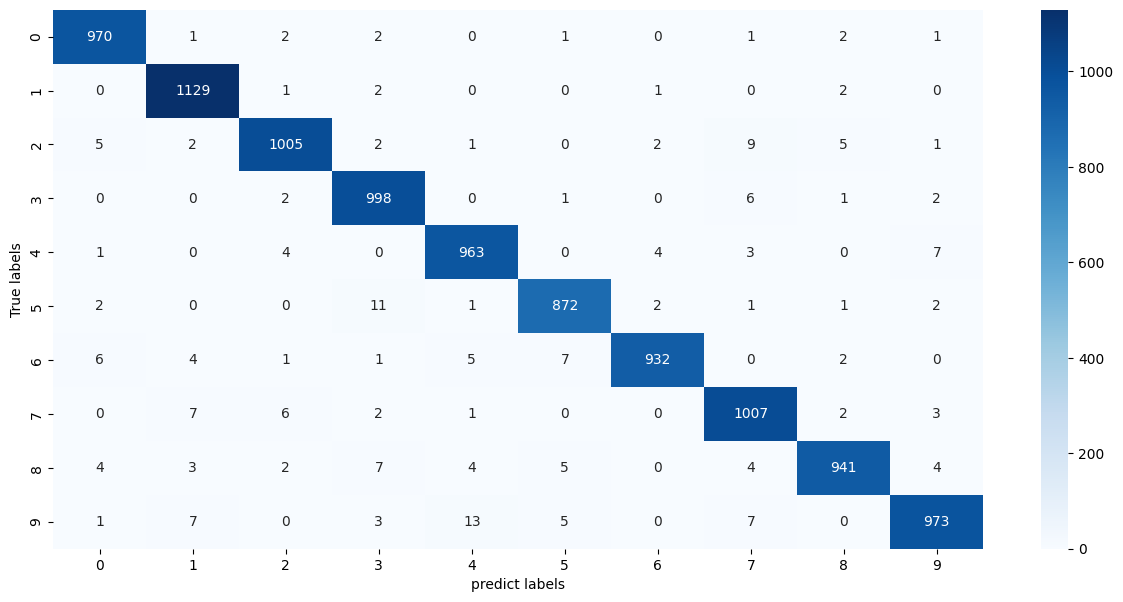

In [87]:
# confusion matrix
conf_mat = confusion_matrix(y_test,y_pred_labels)
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True labels')
plt.xlabel('predict labels')
plt.show()

### build a predictive system

In [88]:
input_img = cv2.imread('image_test.png')
# convert to grayscale
grayscale = cv2.cvtColor(input_img, cv2.COLOR_BGR2GRAY)
# resize
input_img_resize = cv2.resize(grayscale, (28,28))
# scale
input_img_scale = input_img_resize/255
# reshape
img_reshape = np.reshape(input_img_scale, [1,28,28])
# predict
prediction = model.predict(img_reshape)
#
pred = np.argmax(prediction)
print(pred)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3
